<a href="https://colab.research.google.com/github/sultaniqalbi/study_grup_ismile_2026/blob/main/Salinan_dari_Hari_1_EDA_%26_Data_Cleaning_(Peserta).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hari 1: EDA & Data Cleaning
**Study Group I-Smile Lab: EDA to Machine Learning**
Rabu, 30 September 2026 · Telkom University

### Tujuan hari ini
Setelah sesi ini kamu bisa:
1. Mengenali isi dataset: arti tiap kolom, tipe data, dan apa yang diwakili satu baris.
2. Menjelajah data (EDA) dengan `value_counts` dan visualisasi untuk menemukan pola dan masalah data.
3. Membersihkan data: menangani missing value, duplikat, dan outlier, lalu melakukan encoding kolom kategorik.
4. Menghasilkan `df_final` yang siap dipakai untuk Regresi Linear di Hari 2.

### Alur sesi
| Waktu | Kegiatan | Isi notebook |
|---|---|---|
| Blok 1 (50 menit) | EDA | Bagian 0 sampai 2 + ringkasan temuan |
| Break (10 menit) | Istirahat | |
| Blok 2 (50 menit) | Data Cleaning | Bagian 3 sampai 7 + penjelasan Tugas 1 |

### Cara pakai notebook ini
1. Di Colab, pilih **File → Simpan salinan di Drive** supaya perubahanmu tersimpan di Drive sendiri.
2. Cari sel bertanda `# TODO`, lalu ganti setiap `___` dengan kode yang tepat.
3. Jalankan sel **berurutan dari atas** dengan **Shift+Enter**. Kalau muncul error `NameError: name '...' is not defined`, berarti ada sel sebelumnya yang belum dijalankan (pakai menu *Runtime → Run before*).

Tanda yang dipakai di notebook ini:
- **Diskusi:** pertanyaan yang kita bahas bareng **sebelum** sel berikutnya dijalankan. Coba tebak dulu jawabannya.
- Blockquote **Di dunia nyata**: versi lanjutan yang dipakai di industri. Cukup dipahami, tidak perlu dipraktikkan.

## 0. Persiapan (± 5 menit)
Kita import library dan membaca dataset. Library yang dipakai hari ini:
- `pandas`: mengolah tabel
- `numpy`: operasi angka
- `matplotlib`: membuat grafik
- `seaborn`: hanya untuk heatmap korelasi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)  # tampilkan semua kolom saat print tabel
plt.rcParams["figure.figsize"] = (8, 4.5)

Lokasi dataset disimpan di satu variabel, `DATA_PATH`. Kalau file-nya pindah (misalnya ke Google Drive), cukup ganti baris itu.

In [ ]:
# Lokasi dataset. Di Colab, ganti dengan link Google Drive, misalnya:
# DATA_PATH = "https://drive.google.com/uc?id=ISI_ID_FILE_DI_SINI"
DATA_PATH = "/content/housing.csv"

df = pd.read_csv(DATA_PATH)
print("Ukuran data (baris, kolom):", df.shape)
df.head()

Ukuran data (baris, kolom): (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Pemanasan dari materi kick-off: lihat tipe data dan jumlah nilai yang terisi (non-null) di tiap kolom.

In [ ]:
# TODO: tampilkan ringkasan tipe data dan jumlah nilai non-null tiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### Kamus kolom
| Kolom | Arti | Catatan |
|---|---|---|
| `longitude` | Garis bujur pusat blok | Makin negatif, makin ke barat (ke arah laut) |
| `latitude` | Garis lintang pusat blok | Makin besar, makin ke utara |
| `housing_median_age` | Median umur rumah di blok | Tahun, dipotong di 52 |
| `total_rooms` | Total ruangan **semua rumah** di blok | Bisa ribuan |
| `total_bedrooms` | Total kamar tidur **semua rumah** di blok | Ada nilai kosong |
| `population` | Jumlah penduduk blok | Orang |
| `households` | Jumlah rumah tangga di blok | Rumah tangga |
| `median_income` | Median pendapatan rumah tangga per tahun | **Satuan 10.000 USD**: nilai 3,5 berarti sekitar 35 ribu USD |
| `median_house_value` | Median harga rumah di blok | USD. **Ini target yang mau ditebak** |
| `ocean_proximity` | Kategori jarak ke laut | Teks, 5 kategori |

**Penting: 1 baris = 1 blok wilayah sensus California tahun 1990, bukan 1 rumah.** Satu blok biasanya berisi ratusan sampai beberapa ribu penduduk. Itu sebabnya `total_rooms` bisa bernilai ribuan, dan harga yang kita tebak adalah *median* harga rumah di blok tersebut.

**Diskusi:** Kalau kita salah mengira 1 baris = 1 rumah, lalu melihat `total_rooms` = 5.000, kesimpulan apa yang keliru?

---
# Blok 1: Exploratory Data Analysis (± 45 menit)
EDA artinya "kenalan" dengan data sebelum membangun model: kolom mana yang penting, ada masalah apa saja, dan pola apa yang terlihat.

## 1. Menghitung isi kategori dengan `value_counts` (± 5 menit)
`value_counts()` menghitung berapa kali tiap nilai muncul. Cocok untuk kolom kategorik.

In [ ]:
# TODO: hitung jumlah baris untuk tiap kategori ocean_proximity
df["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
# Versi persen: normalize=True membagi dengan total baris
(df["ocean_proximity"].value_counts(normalize=True) * 100).round(2)

,proportion
ocean_proximity,
<1H OCEAN,44.26
INLAND,31.74
NEAR OCEAN,12.88
NEAR BAY,11.09
ISLAND,0.02


**Diskusi:** `ISLAND` hanya punya 5 baris (sekitar 0,02%). Seberapa bisa dipercaya rata-rata harga yang dihitung dari 5 baris? Apa yang terjadi kalau nanti data dibagi menjadi data latih dan data uji, lalu kelima baris ISLAND semuanya jatuh ke data uji?

> **Di dunia nyata (cukup dipahami, tidak dipraktikkan):** Kategori yang sangat jarang biasanya digabung menjadi satu kategori "Lainnya", atau data dibagi dengan *stratified split* supaya proporsi tiap kategori di data latih dan data uji tetap sama.

## 2. Visualisasi (± 30 menit)
Angka ringkasan saja bisa menipu. Grafik membantu kita melihat **bentuk sebaran** dan **hubungan antar kolom**. Kodenya sengaja dibuat pendek, karena yang penting adalah **membaca** grafiknya. Sebelum pindah ke grafik berikutnya, kita diskusikan dulu apa yang terlihat.

### 2a. Sebaran target: histogram `median_house_value` (± 6 menit)
Histogram membagi rentang nilai menjadi beberapa "wadah" (*bins*), lalu menghitung berapa baris yang masuk ke tiap wadah.

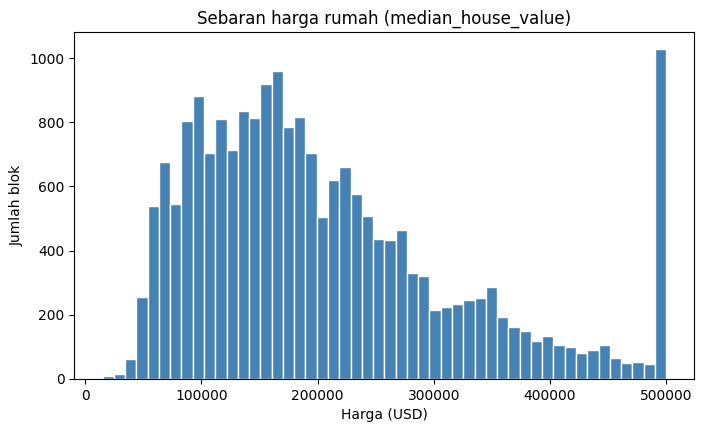

In [ ]:
# TODO: buat histogram median_house_value dengan 50 bins
plt.hist(df["median_house_value"], bins=50, color="steelblue", edgecolor="white")
plt.title("Sebaran harga rumah (median_house_value)")
plt.xlabel("Harga (USD)")
plt.ylabel("Jumlah blok")
plt.show()

**Diskusi:** Perhatikan batang di **ujung paling kanan**. Kenapa batang itu tiba-tiba jauh lebih tinggi daripada batang-batang di sebelahnya?

In [ ]:
# TODO: hitung berapa baris yang harganya tepat 500001
jumlah_capped = (df["median_house_value"]== 500001).sum()
print("Baris dengan harga tepat 500001:", jumlah_capped)

Baris dengan harga tepat 500001: 965


Harga di dataset ini **dipotong (*capped*)**: semua blok dengan harga 500 ribu USD ke atas dicatat sebagai **500.001**. Jadi rumah seharga 600 ribu maupun 2 juta USD sama-sama tertulis 500.001.

Dampaknya ke model: model **tidak pernah melihat** harga di atas 500 ribu USD, sehingga tebakannya untuk blok yang sangat mahal pasti terlalu rendah. Ini keterbatasan data yang perlu dicatat.

### 2b. Pola yang sama di `housing_median_age` (± 3 menit)

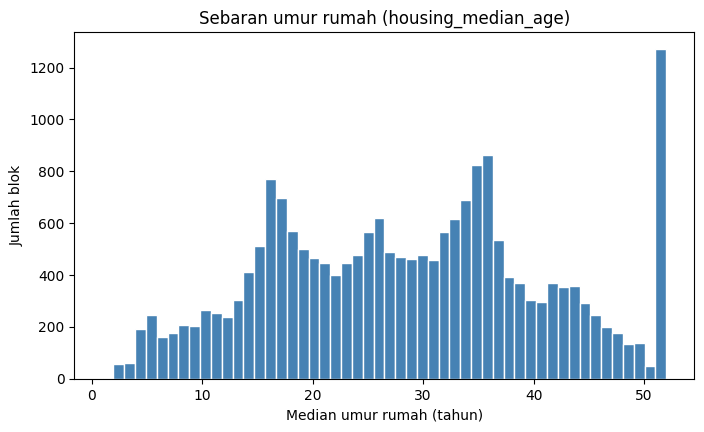

Baris dengan umur tepat 52: 1273


In [ ]:
plt.hist(df["housing_median_age"], bins=52, color="steelblue", edgecolor="white")
plt.title("Sebaran umur rumah (housing_median_age)")
plt.xlabel("Median umur rumah (tahun)")
plt.ylabel("Jumlah blok")
plt.show()

print("Baris dengan umur tepat 52:", (df["housing_median_age"] == 52).sum())

Ada lonjakan di angka **52**: umur rumah juga dipotong. Blok dengan rumah berumur 52 tahun atau lebih semuanya tercatat 52.

### 2c. Sebaran `median_income` (± 4 menit)

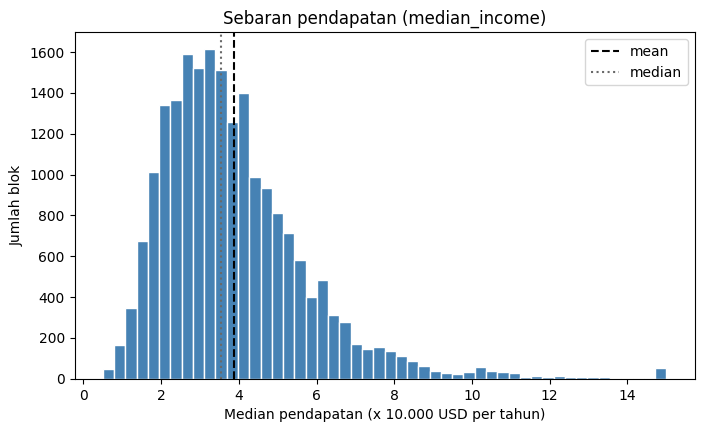

In [ ]:
# TODO: buat histogram median_income dengan 50 bins
plt.hist(df["median_income"], bins=50, color="steelblue", edgecolor="white")
plt.axvline(df["median_income"].mean(), color="black", linestyle="--", label="mean")
plt.axvline(df["median_income"].median(), color="dimgray", linestyle=":", label="median")
plt.title("Sebaran pendapatan (median_income)")
plt.xlabel("Median pendapatan (x 10.000 USD per tahun)")
plt.ylabel("Jumlah blok")
plt.legend()
plt.show()

Sebarannya **miring ke kanan** (*right-skewed*): sebagian besar blok berpendapatan menengah, tapi ada ekor panjang berisi blok yang sangat kaya. Ekor ini "menarik" **mean** ke kanan, sehingga mean lebih besar daripada **median**.

Simpan pengamatan ini: di Blok 2 kita akan memilih antara mean dan median untuk mengisi nilai yang kosong.

### 2d. Hubungan pendapatan dan harga: scatter plot (± 5 menit)
Scatter plot menggambar satu titik untuk tiap baris. Karena titiknya ada lebih dari 20 ribu, kita pakai `alpha` kecil (transparan) supaya area yang padat terlihat lebih gelap.

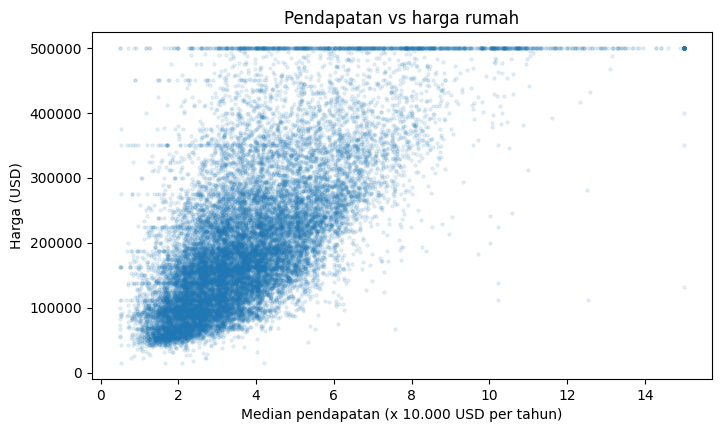

In [ ]:
# TODO: scatter median_income (sumbu x) vs median_house_value (sumbu y), dengan alpha=0.1
plt.scatter(df["median_income"], df["median_house_value"], alpha=0.1, s=5)
plt.title("Pendapatan vs harga rumah")
plt.xlabel("Median pendapatan (x 10.000 USD per tahun)")
plt.ylabel("Harga (USD)")
plt.show()

**Diskusi:** (1) Bagaimana arah hubungannya: makin besar pendapatan, harga cenderung makin apa? (2) Ada garis mendatar yang jelas di bagian paling atas. Garis apa itu? (3) Kenapa kita pakai `alpha=0.1`, bukan `alpha=1`?

### 2e. "Peta" California (± 4 menit)
`longitude` dan `latitude` bisa langsung digambar sebagai peta. Warna titik menunjukkan harga.

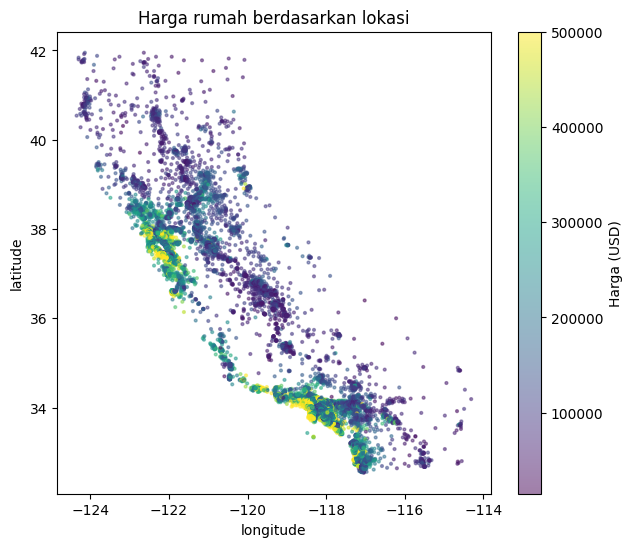

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(df["longitude"], df["latitude"], c=df["median_house_value"],
            cmap="viridis", s=4, alpha=0.5)
plt.colorbar(label="Harga (USD)")
plt.title("Harga rumah berdasarkan lokasi")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

Blok termahal (kuning) berkumpul di **pesisir**, terutama di sekitar San Francisco Bay Area (atas) dan Los Angeles (bawah). Lokasi jelas penting, tapi hubungannya **tidak berupa garis lurus**: harga tidak naik terus-menerus ketika longitude bertambah, melainkan tinggi di titik-titik tertentu.

### 2f. Harga per kategori `ocean_proximity`: boxplot (± 4 menit)
Peta tadi menunjukkan pesisir lebih mahal. Sekarang kita cek hal yang sama lewat kolom `ocean_proximity`. Boxplot meringkas sebaran harga tiap kategori: garis di tengah kotak adalah **median**, kotaknya berisi 50% data di tengah, dan kumisnya menunjukkan rentang sisanya. Kategori diurutkan dari median termurah.

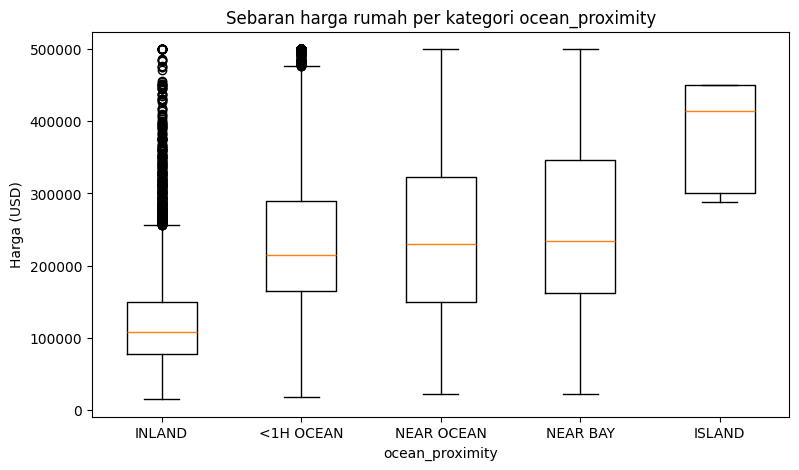

,median_house_value
ocean_proximity,
INLAND,108500.0
<1H OCEAN,214850.0
NEAR OCEAN,229450.0
NEAR BAY,233800.0
ISLAND,414700.0


In [ ]:
# Median harga tiap kategori, diurutkan dari termurah (dipakai untuk mengurutkan kotak)
median_per_kategori = df.groupby("ocean_proximity")["median_house_value"].median().sort_values()
urutan = median_per_kategori.index
harga_per_kategori = [df.loc[df["ocean_proximity"] == k, "median_house_value"] for k in urutan]

plt.figure(figsize=(9, 5))
plt.boxplot(harga_per_kategori)
plt.xticks(range(1, len(urutan) + 1), urutan)
plt.title("Sebaran harga rumah per kategori ocean_proximity")
plt.xlabel("ocean_proximity")
plt.ylabel("Harga (USD)")
plt.show()

median_per_kategori

**Diskusi:** Kategori mana yang paling beda sendiri? Apa artinya bagi model? Kenapa kotak ISLAND terlihat aneh?

### 2g. Heatmap korelasi (± 4 menit)
Korelasi mengukur seberapa kuat dua kolom bergerak bersama **dalam garis lurus**. Nilainya dari -1 sampai 1: mendekati 1 berarti naik bersama, mendekati -1 berarti berlawanan arah, dan mendekati 0 berarti tidak ada hubungan garis lurus.

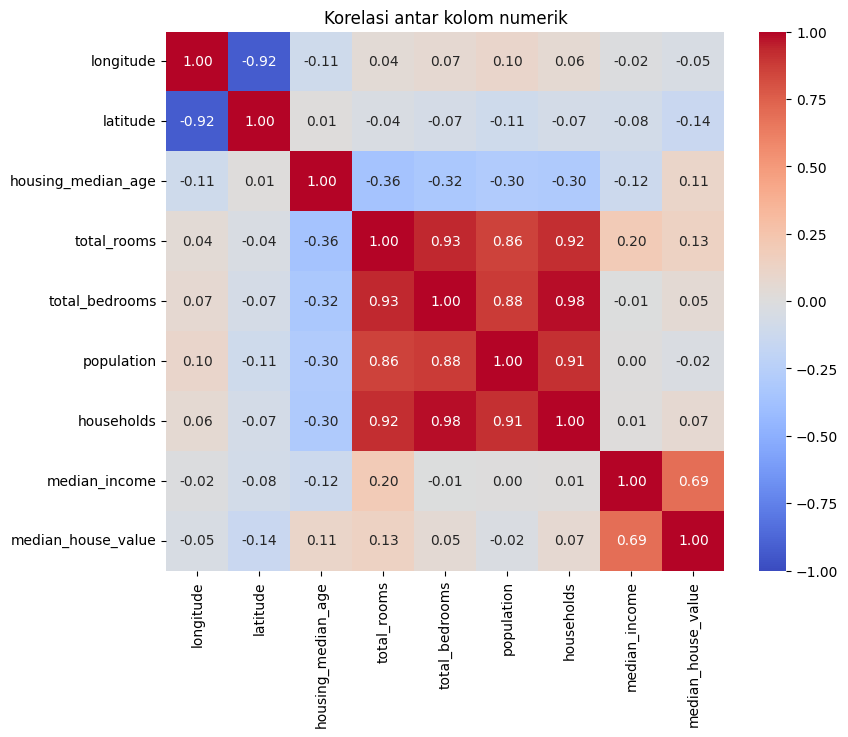

,median_house_value
median_house_value,1.00
median_income,0.69
total_rooms,0.13
housing_median_age,0.11
households,0.07
total_bedrooms,0.05
population,-0.02
longitude,-0.05
latitude,-0.14


In [ ]:
korelasi = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(korelasi, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Korelasi antar kolom numerik")
plt.show()

korelasi["median_house_value"].sort_values(ascending=False).round(2)

> **Di dunia nyata (cukup dipahami, tidak dipraktikkan):** Sebelum membangun model, tim data biasanya membuat laporan EDA lengkap yang juga dibagi per wilayah atau per waktu. Mereka juga membuat fitur baru dari kolom yang ada, misalnya `rooms_per_household = total_rooms / households`, yang sering lebih bermakna daripada angka total per blok.

### Ringkasan temuan EDA (± 5 menit)
| Temuan | Bukti | Tindak lanjut |
|---|---|---|
| `total_bedrooms` punya nilai kosong | `info()`: 20.473 dari 20.680 terisi | Diisi di Bagian 3 |
| `median_income` miring ke kanan | Histogram 2c: mean > median | Bekal memilih median di Bagian 3 |
| Harga dan umur rumah dipotong | Lonjakan di 500.001 (2a) dan 52 (2b) | Dicatat sebagai keterbatasan data |
| `median_income` paling berhubungan dengan harga | Scatter 2d, korelasi ± 0,69 (2g) | Fitur utama regresi di Hari 2 |
| `ocean_proximity` punya sinyal | Boxplot harga per kategori (2f) | Perlu diubah menjadi angka (Bagian 6) |
| Lokasi penting tapi tidak lurus | Peta 2e | Diingat saat membaca hasil model |

Masih ada yang belum dicek: **baris dobel** dan **nilai ekstrem**. Keduanya dibahas di Blok 2.

---
# Break (10 menit)
Istirahat dulu. Pastikan semua sel di atas sudah jalan tanpa error sebelum lanjut.

---

# Blok 2: Data Cleaning (± 45 menit)
Semua pembersihan dilakukan di **salinan** data, yaitu `df_clean`, supaya `df` asli tetap utuh dan bisa dibandingkan.

Kenapa pakai `.copy()`? Kalau hanya menulis `df_clean = df`, kedua nama itu menunjuk ke tabel yang **sama**, sehingga mengubah salah satunya ikut mengubah yang lain.

In [ ]:
df_clean = df.copy()
print("Ukuran df_clean:", df_clean.shape)

Ukuran df_clean: (20640, 10)


In [ ]:
# Menjalankan ulang sel inisialisasi df_clean.
df_clean = df.copy()
print("Ukuran df_clean setelah direset:", df_clean.shape)

Ukuran df_clean setelah direset: (20640, 10)


## 3. Missing value (± 12 menit)
Langkah pertama: cari tahu kolom mana yang kosong dan berapa banyak.

In [ ]:
df_clean.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
# Versi persen: mean() dari True/False = proporsi yang True
(df_clean.isnull().mean() * 100).round(2)

,0
longitude,0.0
latitude,0.0
housing_median_age,0.0
total_rooms,0.0
total_bedrooms,1.0
population,0.0
households,0.0
median_income,0.0
median_house_value,0.0
ocean_proximity,0.0


### Pilihan penanganan missing value
| Pilihan | Cara di pandas | Cocok kalau... | Risiko |
|---|---|---|---|
| Buang baris | `df.dropna()` | Baris kosong sangat sedikit dan acak | Kehilangan data |
| Buang kolom | `df.drop(columns=[...])` | Sebagian besar isi kolom kosong, atau kolomnya tidak penting | Kehilangan seluruh informasi kolom |
| Isi mean / median | `df[kolom].fillna(...)` | Kolom **numerik** | Mean mudah tertarik nilai ekstrem |
| Isi modus (nilai terbanyak) | `df[kolom].fillna(df[kolom].mode()[0])` | Kolom **kategorik** | Kategori terbanyak jadi makin dominan |

`total_bedrooms` kosong sekitar 1% dan kolomnya numerik, jadi kita akan **mengisinya**.

**Diskusi:** `total_bedrooms` itu numerik, jadi nilai kosongnya diisi pakai apa, **mean** atau **median**? Ingat bentuk histogram `median_income` di 2c. Kolom jumlah seperti ini biasanya juga miring ke kanan.

In [ ]:
print("Mean   total_bedrooms:", round(df_clean["total_bedrooms"].mean(), 1))
print("Median total_bedrooms:", df_clean["total_bedrooms"].median())

Mean   total_bedrooms: 537.9
Median total_bedrooms: 435.0


Mean lebih besar daripada median karena ada blok raksasa dengan ribuan kamar tidur yang menarik mean ke atas. **Median lebih tahan terhadap nilai ekstrem**, jadi kita pilih median.

Sebelum mengisi, coba lihat dulu seberapa banyak data yang hilang kalau kita memilih jalan pintas `dropna()`:

In [ ]:
# Demo saja: hasil dropna() TIDAK disimpan ke df_clean
print("Baris sebelum dropna :", len(df_clean))
print("Baris sesudah dropna :", len(df_clean.dropna()))
print("Baris yang hilang    :", len(df_clean) - len(df_clean.dropna()))

Baris sebelum dropna : 20640
Baris sesudah dropna : 20433
Baris yang hilang    : 207


Sekarang isi nilai kosong dengan median. Perhatikan bahwa hasil `fillna` harus **disimpan kembali** (di-*assign* ulang) ke kolomnya. Kalau tidak, `df_clean` tidak berubah.

In [ ]:
# TODO: isi nilai kosong total_bedrooms dengan median, lalu simpan kembali ke kolomnya
median_bedrooms = df_clean["total_bedrooms"].median()
df_clean["total_bedrooms"] = df_clean["total_bedrooms"].fillna(median_bedrooms)

print("Sisa missing total_bedrooms:", df_clean["total_bedrooms"].isnull().sum())

Sisa missing total_bedrooms: 0


> **Di dunia nyata (cukup dipahami, tidak dipraktikkan):** Satu angka median untuk seluruh California itu kasar. Tim data biasanya mengisi dengan **median per wilayah** (misalnya per `ocean_proximity`, dengan `groupby(...).transform("median")`), atau **mengestimasi dari kolom lain**. Contohnya, jumlah kamar tidur hampir sebanding dengan `households`, jadi nilainya bisa ditebak dari rasio kamar tidur per rumah tangga. Buktinya di data ini: mengisi dengan angka 435 membuat **5 blok kecil punya kamar tidur lebih banyak daripada total ruangannya**, dan itu mustahil. Selain itu, nilai pengisi seharusnya dihitung dari data latih saja (akan dijelaskan di Hari 2).

## 4. Duplikat (± 5 menit)
Baris duplikat adalah baris yang **semua kolomnya sama persis** dengan baris lain. Duplikat biasanya muncul karena data digabung dari beberapa sumber atau terekam dua kali.

In [ ]:
# TODO: hitung jumlah baris duplikat
df_clean.duplicated().sum()

np.int64(0)

`duplicated()` hanya menandai salinan kedua dan seterusnya. Supaya baris asli dan salinannya tampil berdampingan, pakai `keep=False` (tandai semua), lalu urutkan:

In [ ]:
contoh_duplikat = df_clean[df_clean.duplicated(keep=False)]
contoh_duplikat.sort_values(["longitude", "latitude"]).head(6)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [ ]:
df_clean = df_clean.drop_duplicates()
print("Ukuran setelah duplikat dibuang:", df_clean.shape)

Ukuran setelah duplikat dibuang: (20640, 10)


**Diskusi:** Di Hari 2, data akan dibagi menjadi **data latih** (untuk belajar) dan **data uji** (untuk "ujian"). Kalau sebuah baris punya kembaran, lalu yang satu masuk data latih dan kembarannya masuk data uji, apa yang terjadi dengan nilai ujian model? Apakah nilainya masih jujur?

> **Di dunia nyata (cukup dipahami, tidak dipraktikkan):** Duplikat sering tidak identik 100%, misalnya transaksi yang sama tercatat dua kali dengan jam yang beda beberapa detik. Karena itu, duplikat biasanya dicek berdasarkan kolom kunci saja, misalnya `drop_duplicates(subset=["id_pelanggan", "tanggal"])`, dan aturannya disepakati dengan pemilik data.

## 5. Outlier (± 13 menit)
Outlier adalah nilai yang **jauh berbeda** dari mayoritas data. Mulai dari ringkasan statistik: bandingkan kolom `75%` dengan `max`.

In [ ]:
df_clean.describe().round(1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.0,20640.0,20640.0,20640.0,20640.0,20640.0,20640.0,20640.0,20640.0
mean,-119.6,35.6,28.6,2635.8,536.8,1425.5,499.5,3.9,206855.8
std,2.0,2.1,12.6,2181.6,419.4,1132.5,382.3,1.9,115395.6
min,-124.4,32.5,1.0,2.0,1.0,3.0,1.0,0.5,14999.0
25%,-121.8,33.9,18.0,1447.8,297.0,787.0,280.0,2.6,119600.0
50%,-118.5,34.3,29.0,2127.0,435.0,1166.0,409.0,3.5,179700.0
75%,-118.0,37.7,37.0,3148.0,643.2,1725.0,605.0,4.7,264725.0
max,-114.3,42.0,52.0,39320.0,6445.0,35682.0,6082.0,15.0,500001.0


Lihat `population`: 75% blok berpenduduk di bawah ± 1.725 orang, tetapi nilai maksimumnya 35.682. Boxplot membuat hal ini terlihat jelas.

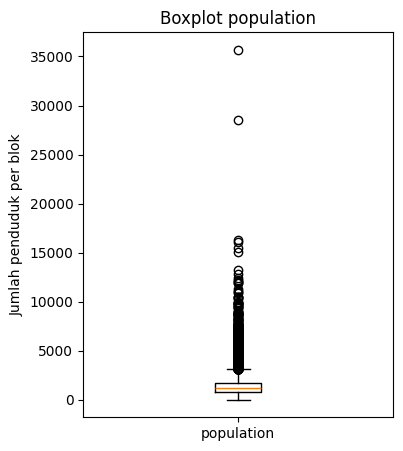

In [ ]:
plt.figure(figsize=(4, 5))
plt.boxplot(df_clean["population"])
plt.title("Boxplot population")
plt.ylabel("Jumlah penduduk per blok")
plt.xticks([1], ["population"])
plt.show()

### Metode IQR
Cara membaca boxplot sekaligus aturan outlier yang paling umum:
1. **Q1** adalah nilai di posisi 25%, dan **Q3** di posisi 75%.
2. **IQR** = Q3 − Q1. Ini lebar "kotak" yang berisi 50% data di tengah.
3. **Batas bawah** = Q1 − 1,5 × IQR, dan **batas atas** = Q3 + 1,5 × IQR.
4. Nilai di luar kedua batas itu dianggap outlier (titik-titik di boxplot).

Demo pada `population`. Untuk mengambil baris outlier, kita pakai filter `df[kondisi]`, yang mengambil baris yang kondisinya `True`. Tanda `|` artinya "atau", dan tiap syarat wajib dibungkus kurung.

In [ ]:
Q1 = df_clean["population"].quantile(0.25)
Q3 = df_clean["population"].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier_pop = df_clean[(df_clean["population"] < batas_bawah) | (df_clean["population"] > batas_atas)]
print(f"Q1 = {Q1:.0f}, Q3 = {Q3:.0f}, IQR = {IQR:.0f}")
print(f"Batas bawah = {batas_bawah:.0f}, batas atas = {batas_atas:.0f}")
print("Jumlah outlier population:", len(outlier_pop))

Q1 = 787, Q3 = 1725, IQR = 938
Batas bawah = -620, batas atas = 3132
Jumlah outlier population: 1196


Giliran kamu: terapkan langkah yang sama ke `total_rooms`.

In [ ]:
# TODO: terapkan metode IQR ke kolom total_rooms
Q1_rooms = df_clean["total_rooms"].quantile(0.25)
Q3_rooms = df_clean["total_rooms"].quantile(0.50)
IQR_rooms = Q3_rooms - Q1_rooms
batas_bawah_rooms = Q1_rooms - 1.5 * IQR_rooms
batas_atas_rooms =Q1_rooms + 1.5 * IQR_rooms

outlier_rooms = df_clean[(df_clean["total_rooms"] < batas_bawah_rooms) | (df_clean["total_rooms"] > batas_atas_rooms)]
print(f"Batas atas total_rooms = {batas_atas_rooms:.0f}")
print("Jumlah outlier total_rooms:", len(outlier_rooms))

Batas atas total_rooms = 2467
Jumlah outlier total_rooms: 8860


**Diskusi:** Outlier ini **salah** atau hanya **jarang**? Lihat tiga blok dengan penduduk terbanyak di bawah ini. Apakah kolom-kolom lainnya (`households`, `total_rooms`) ikut besar dan masuk akal, atau ada yang janggal seperti salah ketik?

In [ ]:
outlier_pop.sort_values("population", ascending=False).head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
15360,-117.42,33.35,14.0,25135.0,4819.0,35682.0,4769.0,2.5729,134400.0,<1H OCEAN
9880,-121.79,36.64,11.0,32627.0,6445.0,28566.0,6082.0,2.3087,118800.0,<1H OCEAN
13139,-121.44,38.43,3.0,39320.0,6210.0,16305.0,5358.0,4.9516,153700.0,INLAND


**Keputusan: outlier dibiarkan.** Blok-blok besar ini nyata. Kolom lainnya ikut besar secara konsisten (penduduk banyak, rumah tangga banyak, ruangan banyak), jadi ini wilayah yang memang padat atau luas, bukan salah catat. Kalau dibuang, kita kehilangan lebih dari seribu blok yang justru merupakan bagian nyata dari California.

Bandingkan dengan **nilai mustahil**, misalnya umur rumah negatif, harga 0, atau kamar tidur lebih banyak daripada total ruangan. Nilai seperti itu **pasti salah** dan harus ditangani. Kasus seperti itu akan kita temui di **Dataset B pada Hari 3**.

Jadi pertanyaan kuncinya bukan "apakah nilainya ekstrem?", melainkan "**apakah nilainya mungkin terjadi?**"

> **Di dunia nyata (cukup dipahami, tidak dipraktikkan):** Kalau outlier nyata tapi mengganggu model, ada dua cara yang umum. **Capping (winsorizing)**: nilai di atas batas diganti dengan batas itu, misalnya `df["population"].clip(upper=batas_atas)`. **Transformasi log**: `np.log1p(df["population"])` membuat sebaran yang miring ke kanan jadi lebih simetris. Model berbasis pohon (decision tree, random forest) juga lebih tahan terhadap outlier daripada regresi linear.

## 6. Encoding kolom kategorik (± 10 menit)
Model machine learning hanya bisa menghitung **angka**, sedangkan `ocean_proximity` masih berupa teks. Kenapa tidak diganti saja dengan angka 0 sampai 4?

| Kategori | Label (salah) |
|---|---|
| `<1H OCEAN` | 0 |
| `INLAND` | 1 |
| `ISLAND` | 2 |
| `NEAR BAY` | 3 |
| `NEAR OCEAN` | 4 |

Dengan label seperti ini, model akan mengira:
- **Ada urutan palsu**: `NEAR OCEAN` (4) dianggap "lebih besar" daripada `INLAND` (1).
- **Ada jarak palsu**: jarak `INLAND` ke `ISLAND` (1 ke 2) dianggap sama dengan jarak `ISLAND` ke `NEAR BAY` (2 ke 3), dan `NEAR OCEAN` dianggap "4 kali" `INLAND`.

Padahal kategorinya hanya **nama**, tanpa urutan. Solusinya adalah **one-hot encoding**: setiap kategori mendapat kolom sendiri berisi 1 (ya) atau 0 (bukan).

In [ ]:
# Intip bentuk one-hot: ambil 1 contoh baris untuk tiap kategori (belum disimpan)
contoh = df_clean.drop_duplicates(subset="ocean_proximity")["ocean_proximity"]
pd.concat([contoh, pd.get_dummies(contoh, dtype=int)], axis=1)

,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,NEAR BAY,0,0,0,1,0
701,<1H OCEAN,1,0,0,0,0
954,INLAND,0,1,0,0,0
1850,NEAR OCEAN,0,0,0,0,1
8314,ISLAND,0,0,1,0,0


In [ ]:
# TODO: ubah ocean_proximity menjadi kolom one-hot, buang kategori pertama, dengan tipe data int
df_final = pd.get_dummies(df_clean, columns=["ocean_proximity"], drop_first=["ocean_proximity"], dtype=int)
print("Ukuran df_final:", df_final.shape)
df_final.head()

Ukuran df_final: (20640, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [ ]:
[kolom for kolom in df_final.columns if kolom.startswith("ocean_proximity")]

['ocean_proximity_INLAND',
 'ocean_proximity_ISLAND',
 'ocean_proximity_NEAR BAY',
 'ocean_proximity_NEAR OCEAN']

**Apa fungsi `drop_first=True`?** Dari 5 kategori, cukup 4 kolom. Kalau keempat kolom bernilai 0, artinya bloknya pasti kategori yang dibuang, yaitu **`<1H OCEAN`** (urutan pertama secara alfabet). Kolom kelima tidak memberi informasi baru, dan kalau tetap ada, regresi linear malah jadi "bingung" karena satu kolom bisa ditebak sempurna dari kolom lainnya.

Kategori yang dibuang menjadi **pembanding** (*baseline*). Di Hari 2, koefisien `ocean_proximity_INLAND` akan dibaca sebagai: "dibandingkan blok `<1H OCEAN`, blok INLAND rata-rata lebih murah sekian USD".

> **Di dunia nyata (cukup dipahami, tidak dipraktikkan):** Kalau kategorinya ribuan (misalnya nama kota), one-hot membuat ribuan kolom. Untuk kasus itu dipakai cara lain seperti menggabungkan kategori langka ke "Lainnya" atau *target encoding*. Di pipeline produksi, encoding dilakukan dengan `OneHotEncoder` dari scikit-learn yang di-*fit* hanya pada data latih dan bisa menangani kategori baru yang belum pernah muncul (`handle_unknown="ignore"`).

## 7. Cek akhir (± 5 menit)
Pastikan `df_final` benar-benar siap dipakai untuk model.

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_INLAND      20640 non-null  int64  
 10  ocean_proximity_ISLAND      20640 non-null  int64  
 11  ocean_proximity_NEAR BAY    20640 non-null  int64  
 12  ocean_proximity_NEAR OCEAN  20640 non-null  int64  
dtypes: float64(9), int64(4)
memory 

In [ ]:
print("Ukuran akhir         :", df_final.shape)
print("Total missing        :", df_final.isnull().sum().sum())
print("Total duplikat       :", df_final.duplicated().sum())
print("Kolom yang bukan angka:", df_final.select_dtypes(exclude="number").columns.tolist())

Ukuran akhir         : (20640, 13)
Total missing        : 0
Total duplikat       : 0
Kolom yang bukan angka: []


### Checklist
- Tidak ada missing value (total missing = 0)
- Tidak ada baris duplikat (total duplikat = 0)
- Semua kolom berupa angka (daftar kolom bukan angka kosong)
- Ukuran akhir 20.640 baris × 13 kolom

### Ringkasan data cleaning
| Masalah | Tindakan | Alasan |
|---|---|---|
| 207 nilai kosong di `total_bedrooms` | Diisi median (435) | Kolom numerik yang miring ke kanan, dan median tahan nilai ekstrem |
| 40 baris duplikat | `drop_duplicates()` | Mencegah data terhitung dua kali dan bocor ke data uji |
| Outlier di `population` & `total_rooms` | **Dibiarkan** | Nilainya nyata (jarang, bukan salah) |
| Harga & umur dipotong di 500.001 / 52 | Dibiarkan, dicatat | Keterbatasan data, bukan kesalahan input |
| `ocean_proximity` berupa teks | One-hot, `drop_first=True` | Model butuh angka tanpa urutan dan jarak palsu |